In [1]:
import csv
import sys
import networkx as nx
import matplotlib.pyplot as plt

import distanceclosure as dc
from distanceclosure.dijkstra import single_source_dijkstra_path_length

In [2]:
# Input
csv_file_path = 'breast_cancer/confidence_rank_unique_temp.csv'

# Output
output_csv_path = 'breast_cancer/confidence_rank_ultrametric.csv'
annotated_csv_path = 'breast_cancer/confidence_rank_unique.csv'

# Parameters
source_col = 'Regulator'
target_col = 'Target'
weight_col = 'Confidence rank'

MANUAL_FIXES = []

# Makes sure that more confident path with matching sign with length up to 10 exists
MANUAL_FIXES = [('ABL1', 'MYOD1'), ('NF2', 'MYOD1'), ('PRAS40', 'PRAS40'), ('PRKACA', 'PRKAA2'), ('RB', 'p53'), ('RPS6', 'NFKB'), ('RPS6', 'RAF1'), ('RPS6', 'RAF1_2'), ('S6K', 'CyclinD'), ('S6K', 'CyclinD_2'), ('S6K', 'Translation'), ('TCF7L2', 'PAK1'), ('YAP1', 'CTNNB1'), ('erlotinib', 'HER3'), ('erlotinib', 'HER3_2'), ('pertuzumab', 'mTORC1')]

In [3]:
edgelist = {}

with open(csv_file_path, mode='r', encoding='utf-8') as file:
    reader = csv.DictReader(file)
    for row in reader:
        # Create the tuple key using the source and target columns
        edge = (row[source_col], row[target_col])
        
        # Convert the weight to an integer (or float if needed)
        weight = int(row[weight_col])
        
        # Add to the dictionary
        edgelist[edge] = weight

print(edgelist)
print(len(edgelist))

{('ABL1', 'JAK2'): 1, ('ABL1', 'MYOD1'): 4, ('ABL1', 'SRC'): 4, ('ABL2', 'CEBPB'): 1, ('AKT', 'AKT'): 2, ('AKT', 'BAD'): 1, ('AKT', 'CASP9'): 1, ('AKT', 'CREB1'): 1, ('AKT', 'CyclinD'): 2, ('AKT', 'CyclinD_2'): 2, ('AKT', 'ESR1'): 1, ('AKT', 'ESR1_2'): 1, ('AKT', 'FAS'): 4, ('AKT', 'FOXO1'): 1, ('AKT', 'FOXO3'): 1, ('AKT', 'GSK3B'): 1, ('AKT', 'HER3'): 2, ('AKT', 'HER3_2'): 2, ('AKT', 'KMT2D'): 1, ('AKT', 'MDM2'): 1, ('AKT', 'NOS3'): 1, ('AKT', 'PRAS40'): 1, ('AKT', 'PRKACA'): 4, ('AKT', 'RAC1'): 1, ('AKT', 'S6K'): 2, ('AKT', 'TSC2'): 1, ('AKT', 'TWIST1'): 1, ('AKT', 'mTORC1'): 2, ('AKT', 'p21'): 1, ('AKT', 'p21_p27'): 1, ('AKT', 'p38'): 3, ('APC', 'DC'): 0, ('AXIN1', 'APC'): 1, ('Alpelisib', 'PI3K'): 1, ('Alpelisib', 'PI3K_2'): 1, ('Apoptosis', 'Apoptosis'): 4, ('Apoptosis_2', 'Apoptosis_2'): 4, ('Apoptosis_3', 'Apoptosis_3'): 4, ('BAD', 'Apoptosis'): 2, ('BAD', 'Apoptosis_2'): 2, ('BAD', 'Apoptosis_3'): 2, ('BAD', 'BCL2'): 1, ('BAD', 'BCLXL'): 1, ('BAK1', 'CYCS'): 1, ('BAX', 'BAX'): 

In [4]:
# Instanciate a (weighted) graph
G = nx.DiGraph()
weighted_edges = [(u, v, w) for (u, v), w in edgelist.items()]

G.add_weighted_edges_from(weighted_edges, weight='distance')

print(f"Nodes: {G.nodes()}")
print(f"Edges: {G.edges(data=True)}")
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Nodes: ['ABL1', 'JAK2', 'MYOD1', 'SRC', 'ABL2', 'CEBPB', 'AKT', 'BAD', 'CASP9', 'CREB1', 'CyclinD', 'CyclinD_2', 'ESR1', 'ESR1_2', 'FAS', 'FOXO1', 'FOXO3', 'GSK3B', 'HER3', 'HER3_2', 'KMT2D', 'MDM2', 'NOS3', 'PRAS40', 'PRKACA', 'RAC1', 'S6K', 'TSC2', 'TWIST1', 'mTORC1', 'p21', 'p21_p27', 'p38', 'APC', 'DC', 'AXIN1', 'Alpelisib', 'PI3K', 'PI3K_2', 'Apoptosis', 'Apoptosis_2', 'Apoptosis_3', 'BCL2', 'BCLXL', 'BAK1', 'CYCS', 'BAX', 'BIM', 'BCL2_T', 'BCLXL_T', 'BID', 'BIM_T', 'CASP3', 'CASP8', 'CDK46', 'CYCLINDc', 'CYCLINDc_2', 'CDKN2A', 'PPARG', 'FZD', 'CTNNB1', 'MYC', 'MYC_2', 'NOTCH1', 'TCF7L2', 'RB', 'pRB', 'pRB_2', 'pRB_3', 'CyclinB1', 'DLL', 'DVL1', 'E2F', 'E2F_2', 'Proliferation', 'Proliferation_3', 'Proliferation_4', 'cycE_CDK2_T', 'E2F_3', 'Proliferation_2', 'EGF', 'EGFR', 'ERK', 'ERK_2', 'HER2', 'PLCg', 'GRB2', 'KRT14', 'MEK', 'MEK_2', 'PDK1_pm', 'RAF1', 'RAF1_2', 'STAT1', 'STAT5', 'EIF4', 'Translation', 'EIF4EBP1', 'ER', 'JUN', 'MCL1', 'STK11', 'FOXO3_Ub', 'ER_transcription', 'ER

In [5]:
B = dc.ultrametric_backbone(G, weight='distance', self_loops=False)

In [6]:
def print_report(graph):
    print(f"Number of nodes: {graph.number_of_nodes()}")
    print(f"Number of edges: {graph.number_of_edges()}")
    print(f"Number of self-loops: {len([e for e in graph.edges() if e[0] == e[1]])}")
    max_in_degree = 0
    max_in_degree_node = None
    log2_number_of_possible_BN = 1
    for node in graph.nodes():
        log2_number_of_possible_BN += 2**graph.in_degree(node)

        if graph.in_degree(node) > max_in_degree:
            max_in_degree = graph.in_degree(node)
            max_in_degree_node = node
    print("node with highest in-degree: ", max_in_degree_node, " with in-degree: ", max_in_degree)
    print("number of possible Boolean Networks: 2^", log2_number_of_possible_BN)

In [7]:
print_report(G)
print()
print_report(B)

Number of nodes: 200
Number of edges: 708
Number of self-loops: 18
node with highest in-degree:  AKT  with in-degree:  20
number of possible Boolean Networks: 2^ 1432410

Number of nodes: 200
Number of edges: 496
Number of self-loops: 0
node with highest in-degree:  PI3K  with in-degree:  10
number of possible Boolean Networks: 2^ 9062


In [8]:
target_nodes = [
    n for n in set(list(G.nodes()) + list(B.nodes()))
    if G.has_edge(n, n) or B.has_edge(n, n)
]

print(f"{len(target_nodes)} target nodes:", target_nodes)


18 target nodes: ['p38', 'EGFR', 'ER_transcription_feedback_2', 'IL6', 'BAX', 'E2F_3', 'PRAS40', 'PTEN', 'HER2', 'AKT', 'PTEN_2', 'p53', 'FASLG', 'Apoptosis_3', 'Apoptosis', 'Apoptosis_2', 'JUN', 'GSK3B']


In [9]:
# --- Helper to process bottleneck cycles per graph ---
def get_bottleneck_cycles(graph, target_nodes):
    # Storage format: { target_node: { neighbor: (path_tuple, max_weight) } }
    results = {}
    
    for node in target_nodes:
        if node not in graph:
            continue
        results[node] = {}
        
        # 1. Capture standalone self-loops directly
        if graph.has_edge(node, node):
            results[node][node] = ((node, node), graph[node][node].get('distance'))
            
        # 2. Use your Dijkstra function to find the minimax return path from successors
        for neighbor in graph.successors(node):
            if neighbor == node:
                continue
                
            paths = {neighbor: [neighbor]}
            weight_fn = lambda v, u, e: e.get('distance')
            
            try:
                # Find the path that minimizes the maximum edge weight back to 'node'
                dist = single_source_dijkstra_path_length(
                    graph, 
                    source=neighbor, 
                    weight_function=weight_fn, 
                    paths=paths, 
                    disjunction=max
                )
                
                # If the target node was reached, a valid optimal bottleneck cycle exists
                if node in dist:
                    path_back = paths[node]
                    full_cycle = [node] + path_back
                    
                    # Total bottleneck is the max of the exit edge and the path back
                    exit_edge_w = graph[node][neighbor].get('distance')
                    cycle_max_w = max(exit_edge_w, dist[node])
                    
                    results[node][neighbor] = (tuple(full_cycle), cycle_max_w)
            except (nx.NodeNotFound, ValueError):
                continue
                
    return results

In [10]:
# Storage format: { target_node: { neighbor: (path_tuple, max_weight) } }
cycles_G = get_bottleneck_cycles(G, target_nodes)
cycles_B = get_bottleneck_cycles(B, target_nodes)

In [11]:
def check_cycles(cycles_G, cycles_B):
    errors = []

    for node in set(cycles_G) | set(cycles_B):
        g_routes = cycles_G.get(node, {})
        b_routes = cycles_B.get(node, {})

        # 1. Every cycle in B must also exist in G with the same weight
        for neighbor, (b_path, b_weight) in b_routes.items():
            g_route = g_routes.get(neighbor)

            if g_route is None:
                errors.append(
                    f"Node '{node}': cycle via '{neighbor}' "
                    f"exists in B but is missing in G."
                )
                continue

            g_path, g_weight = g_route

            if g_weight != b_weight:
                errors.append(
                    f"Node '{node}': cycle via '{neighbor}' has "
                    f"different weights: G={g_weight}, B={b_weight}."
                )

        # 2. Global minimum cycle weight must agree
        if g_routes and b_routes:
            min_weight_G = min(w for path, w in g_routes.values())
            min_weight_B = min(w for path, w in b_routes.values())

            if min_weight_G != min_weight_B:
                errors.append(
                    f"Node '{node}': minimum cycle weight differs: "
                    f"G={min_weight_G}, B={min_weight_B}."
                )

        elif g_routes and not b_routes:
            errors.append(
                f"Node '{node}': G has cycles but B has none."
            )

    return errors

In [12]:
errors = check_cycles(cycles_G, cycles_B)

if errors:
    print("Cycle check failed:")
    for error in errors:
        print(" -", error)
else:
    print("Cycle check passed.")

Cycle check failed:
 - Node 'Apoptosis_2': G has cycles but B has none.
 - Node 'FASLG': G has cycles but B has none.
 - Node 'Apoptosis_3': G has cycles but B has none.
 - Node 'BAX': G has cycles but B has none.
 - Node 'Apoptosis': G has cycles but B has none.


In [13]:
def find_self_edges_to_restore(G, B, cycles_G):
    self_edges_to_restore = []

    for node in G.nodes:
        if not G.has_edge(node, node):
            continue

        if B.has_edge(node, node):
            continue

        g_routes = cycles_G.get(node, {})
        if not g_routes:
            continue

        min_weight_G = min(weight for path, weight in g_routes.values())
        self_weight_G = G[node][node].get('distance')

        if self_weight_G == min_weight_G:
            self_edges_to_restore.append(
                (node, node, G[node][node])
            )
            print(f"Found self-edge to restore: {node}, weight: {self_weight_G}")

    return self_edges_to_restore

In [14]:
self_edges_to_restore = find_self_edges_to_restore(
    G, B, cycles_G
)

B2 = B.copy()
B2.add_edges_from(self_edges_to_restore)

Found self-edge to restore: GSK3B, weight: 1
Found self-edge to restore: Apoptosis, weight: 4
Found self-edge to restore: Apoptosis_2, weight: 4
Found self-edge to restore: Apoptosis_3, weight: 4
Found self-edge to restore: BAX, weight: 1
Found self-edge to restore: E2F_3, weight: 1
Found self-edge to restore: EGFR, weight: 1
Found self-edge to restore: HER2, weight: 1
Found self-edge to restore: JUN, weight: 1
Found self-edge to restore: ER_transcription_feedback_2, weight: 4
Found self-edge to restore: FASLG, weight: 2
Found self-edge to restore: IL6, weight: 2
Found self-edge to restore: p53, weight: 1


In [15]:
cycles_B2 = get_bottleneck_cycles(B2, target_nodes)

In [16]:
errors = check_cycles(cycles_G, cycles_B2)

if errors:
    print("Cycle check failed:")
    for error in errors:
        print(" -", error)
else:
    print("Cycle check passed.")

Cycle check passed.


In [17]:
self_edges_to_restore = find_self_edges_to_restore(
    G, B2, cycles_G
)

if self_edges_to_restore:
    print(f"Found {len(self_edges_to_restore)} self-edges to restore.")
else:
    print("No self-edges to restore.")

No self-edges to restore.


In [18]:
print_report(G)
print()
print_report(B2)

Number of nodes: 200
Number of edges: 708
Number of self-loops: 18
node with highest in-degree:  AKT  with in-degree:  20
number of possible Boolean Networks: 2^ 1432410

Number of nodes: 200
Number of edges: 509
Number of self-loops: 13
node with highest in-degree:  PI3K  with in-degree:  10
number of possible Boolean Networks: 2^ 9600


In [19]:
print("\n--- PHASE 3: MANUALLY RESTORING EDGES TO B ---")
B3 = B2.copy()
if MANUAL_FIXES:
    print(f"Adding {len(MANUAL_FIXES)} edges back into Graph B...")

    edges_to_add = []
    for edge in MANUAL_FIXES:
        u, v = edge
        edges_to_add.append((u, v, G[u][v]))

    B3.add_edges_from(edges_to_add)
    
    # Recalculate bottleneck paths for B now that it has been altered
    cycles_B_updated = get_bottleneck_cycles(B3, target_nodes)
else:
    print("No target nodes triggered the condition. Graph B remains unchanged.")


--- PHASE 3: MANUALLY RESTORING EDGES TO B ---
Adding 16 edges back into Graph B...


In [20]:
print_report(G)
print()
print_report(B3)

Number of nodes: 200
Number of edges: 708
Number of self-loops: 18
node with highest in-degree:  AKT  with in-degree:  20
number of possible Boolean Networks: 2^ 1432410

Number of nodes: 200
Number of edges: 525
Number of self-loops: 14
node with highest in-degree:  PI3K  with in-degree:  10
number of possible Boolean Networks: 2^ 9922


In [21]:
# 2. Map Graph B edges into a dictionary for instant lookups
edges_B3_dict = {}
for u, v, data in B3.edges(data=True):
    weight_val = data.get('distance')
    edges_B3_dict[(str(u), str(v))] = weight_val

# 3. Stream through the input CSV and write to both outputs simultaneously
matching_rows_count = 0
total_rows_count = 0
line_number = 1

with open(csv_file_path, mode='r', encoding='utf-8') as infile, \
     open(output_csv_path, mode='w', encoding='utf-8', newline='') as filtered_file, \
     open(annotated_csv_path, mode='w', encoding='utf-8', newline='') as annotated_file:
    
    reader = csv.DictReader(infile)
    
    # Setup Output 1: Filtered file (identical columns to input)
    filtered_writer = csv.DictWriter(filtered_file, fieldnames=reader.fieldnames)
    filtered_writer.writeheader()
    
    # Setup Output 2: Annotated file (input columns + the new extra status column)
    annotated_fieldnames = list(reader.fieldnames) + ['is_kept']
    annotated_writer = csv.DictWriter(annotated_file, fieldnames=annotated_fieldnames)
    annotated_writer.writeheader()
    
    for row in reader:
        line_number += 1
        total_rows_count += 1
        
        row_src = str(row[source_col])
        row_tgt = str(row[target_col])
        
        try:
            # Change int() to float() if your weights contain decimals
            row_weight = int(row[weight_col]) 
            is_valid_weight = True
        except (ValueError, TypeError):
            print(f"⚠️ Warning: Non-numeric weight skipped on line {line_number}.", file=sys.stderr)
            is_valid_weight = False
            
        edge_key = (row_src, row_tgt)
        is_kept = False
        
        # Evaluate if the edge matches Graph B criteria
        if is_valid_weight and (edge_key in edges_B3_dict):
            graph_weight = edges_B3_dict[edge_key]
            
            if row_weight == graph_weight:
                is_kept = True
            else:
                print(f"⚠️ Weight Mismatch Warning [Line {line_number}]: Connection ({row_src} -> {row_tgt}) "
                      f"found in B, but weights disagree! (CSV: {row_weight} vs Graph B: {graph_weight})")
        
        # --- Handle Output 1 (Filtered) ---
        if is_kept:
            filtered_writer.writerow(row)
            matching_rows_count += 1
            
        # --- Handle Output 2 (Annotated) ---
        # Make a copy of the row so we don't accidentally modify the row dat2 used by other operations
        annotated_row = dict(row)
        annotated_row['is_kept'] = "KEPT" if is_kept else "TAKEN_OUT"
        annotated_writer.writerow(annotated_row)

print("\n🎉 Done! Processing completed successfully.")
print(f"   * Total original rows processed: {total_rows_count}")
print(f"   * Filtered output created: '{output_csv_path}' ({matching_rows_count} rows)")
print(f"   * Annotated output created: '{annotated_csv_path}' ({total_rows_count} rows)")



🎉 Done! Processing completed successfully.
   * Total original rows processed: 708
   * Filtered output created: 'breast_cancer/confidence_rank_ultrametric.csv' (525 rows)
   * Annotated output created: 'breast_cancer/confidence_rank_unique.csv' (708 rows)


In [22]:
def plot_node_degree_reduction_profile_v3(G, B, label_G="Original Graph", label_B="Ultrametric Backbone"):
    """
    Plots a stacked bar chart for each node, ordered by original in-degree.
    Features an anonymous visibility baseline to anchor zero-degree nodes.
    """
    # 1. Collect in-degrees for each node across both networks
    node_profiles = []
    for node in G.nodes():
        deg_G = G.in_degree(node)
        deg_B = B.in_degree(node) if node in B else 0
        deg_removed = deg_G - deg_B
        
        node_profiles.append({
            'node': str(node),
            'original': deg_G,
            'retained': deg_B,
            'removed': deg_removed
        })
        
    # 2. Sort the nodes from smallest to largest original in-degree
    node_profiles.sort(key=lambda x: (x['original'], x['retained']))
    
    # 3. Extract the ordered data arrays
    x_indices = range(len(node_profiles))
    retained_amounts = [item['retained'] for item in node_profiles]
    removed_amounts = [item['removed'] for item in node_profiles]
    node_labels = [item['node'] for item in node_profiles]
    
    # 4. Initialize the plot canvas
    plt.figure(figsize=(16, 6))
    
    # --- FIXED: Anonymized Baseline ---
    # Omitting the 'label' argument completely hides this from the legend box
    plt.bar(x_indices, [0.08] * len(node_profiles), color='#D3D3D3', 
            edgecolor='none', linewidth=0)
    
    # Bottom layer: Retained edges in Graph B
    plt.bar(x_indices, retained_amounts, color='royalblue', edgecolor='black', 
            alpha=0.85, label=f"{label_B}", linewidth=0.5)
    
    # Top layer: Removed edges (stacked on top of the retained amounts)
    plt.bar(x_indices, removed_amounts, bottom=retained_amounts, color='crimson', 
            edgecolor='black', alpha=0.85, label="Reduced", linewidth=0.5)
    
    # 5. Aesthetics and Formatting
    plt.title("Node-by-Node In-Degree Reduction Profile", fontsize=14, weight='bold')
    plt.xlabel("Individual Nodes (Ordered from Smallest to Largest Original In-Degree)", fontsize=12)
    plt.ylabel("In-Degree Count", fontsize=12)
    
    # Clear X-axis ticks text distribution for ~100 nodes
    tick_step = 1  
    plt.xticks(
        list(x_indices)[::tick_step], 
        node_labels[::tick_step], 
        rotation=90, 
        ha='center', 
        fontsize=8
    )
    
    # Bold the labels for nodes that started at zero in-degree
    ax = plt.gca()
    for tick_label, profile in zip(ax.get_xticklabels(), node_profiles[::tick_step]):
        if profile['original'] == 0:
            tick_label.set_color('dimgray')
            tick_label.set_weight('bold')
            
    # Set boundaries tightly so the floor stays visually anchored
    plt.ylim(0, max([item['original'] for item in node_profiles]) + 1)
    
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(fontsize=11, loc='upper left')
    
    plt.tight_layout()
    plt.show()

# --- Execution ---
# plot_node_degree_reduction_profile_v3(G, B)


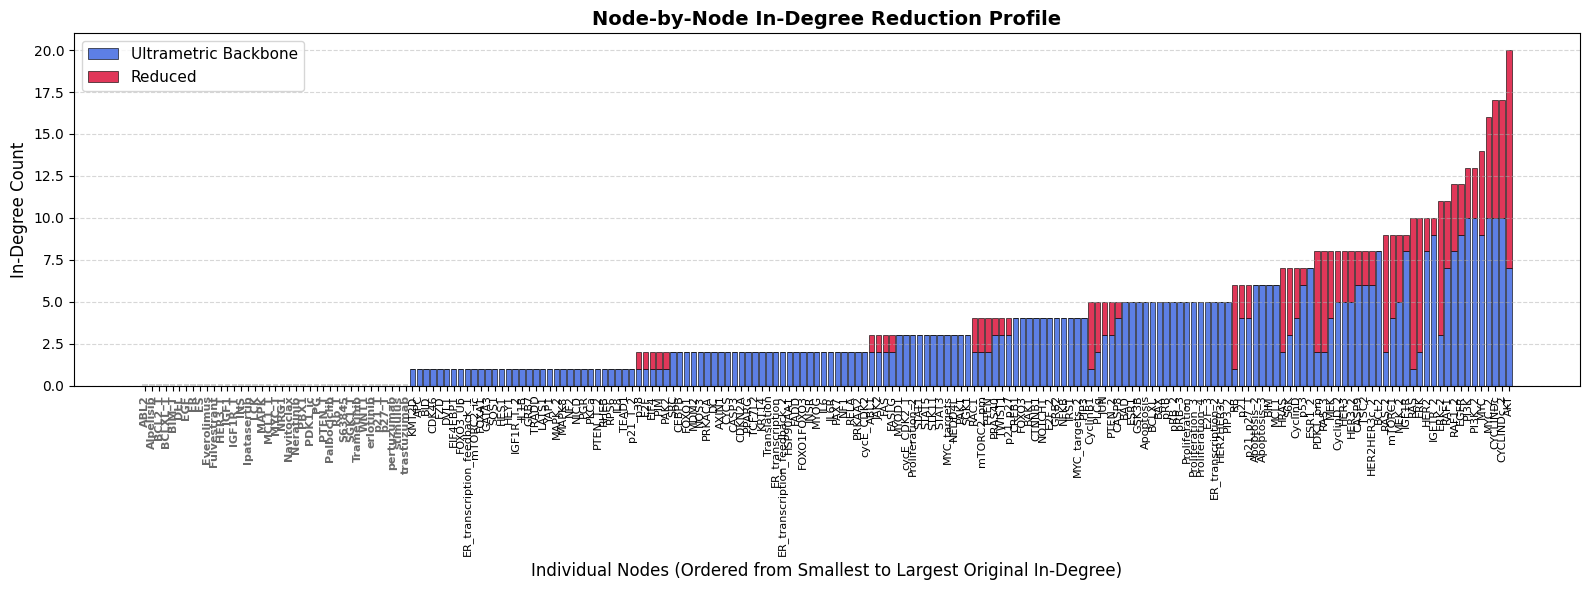

In [23]:
plot_node_degree_reduction_profile_v3(G, B3)

In [24]:
# 0. Find weakly connected components
wccs = list(nx.weakly_connected_components(B3))

print(f"{len(wccs)} Weakly Connected Components")

if len(wccs) > 1:
    print("Nodes in each weakly connected component:")
    for i, wcc in enumerate(wccs, 1):
        print(f"  WCC {i} with {len(wcc)} nodes: {sorted(wcc)}")


# 1. Find source nodes
#    Only has an incoming edge from itself
source_nodes = {
    n for n in B3
    if B3.in_degree(n) == 0
    or (B3.in_degree(n) == 1 and B3.has_edge(n, n))
}

# 2. Find sink nodes
#    Does not regulate any other node
sink_nodes = {
    n for n in B3
    if all(target == n for _, target in B3.out_edges(n))
}


# Output
print(f"{len(source_nodes)} source nodes:", sorted(source_nodes))
print(f"{len(sink_nodes)} sink nodes:", sorted(sink_nodes))

# Largest WCC
largest_wcc = max(nx.weakly_connected_components(B3), key=len)
W = B3.subgraph(largest_wcc)

# All SCCs in the largest WCC, sorted by size
sccs = sorted(
    nx.strongly_connected_components(W),
    key=len,
    reverse=True
)

# assert that SCCs form a partition
assert len(set().union(*sccs)) == len(W)
assert sum(map(len, sccs)) == len(W)

print(f"Largest WCC: {len(W)} nodes")
print(f"Number of SCCs: {len(sccs)}")

scc_dict = {}
index = 1
for scc in sccs:

    # Ignore trivial SCCs that are source or sink nodes
    if len(scc) == 1:
        continue

    # Nodes that can reach the SCC
    in_nodes = set().union(
        *(nx.descendants(W.reverse(copy=False), n) for n in scc)
    )
    in_components = in_nodes - scc

    # Nodes reachable from the SCC
    out_nodes = set().union(
        *(nx.descendants(W, n) for n in scc)
    )
    out_components = out_nodes - scc

    # Nodes in the WCC that are neither the SCC nor its
    # in/out components
    remaining = set(W) - scc - in_components - out_components

    scc_dict[index] = {
        "scc": scc,
        "in": in_components,
        "out": out_components,
        "remaining": remaining
    }
    index += 1


3 Weakly Connected Components
Nodes in each weakly connected component:
  WCC 1 with 196 nodes: ['ABL1', 'ABL2', 'AKT', 'APC', 'AXIN1', 'Alpelisib', 'Apoptosis', 'Apoptosis_2', 'Apoptosis_3', 'BAD', 'BAK1', 'BAX', 'BCL2', 'BCL2_T', 'BCLXL', 'BCLXL_T', 'BID', 'BIM', 'BIM_T', 'CASP3', 'CASP8', 'CASP9', 'CDK46', 'CDKN2A', 'CEBPB', 'CREB1', 'CTNNB1', 'CYCLINDc', 'CYCLINDc_2', 'CYCS', 'CyclinB1', 'CyclinD', 'CyclinD_2', 'DC', 'DLL', 'DVL1', 'E2F', 'E2F_2', 'E2F_3', 'EGF', 'EGFR', 'EIF4', 'EIF4EBP1', 'ER', 'ERK', 'ERK_2', 'ER_transcription', 'ER_transcription_2', 'ER_transcription_feedback_1', 'ER_transcription_feedback_2', 'ES', 'ESR1', 'ESR1_2', 'Everolimus', 'FADD', 'FAS', 'FASLG', 'FOXA1', 'FOXO1', 'FOXO1FOXO3', 'FOXO3', 'FOXO3_Ub', 'FZD', 'Fulvestrant', 'GATA3', 'GRB2', 'GRB7', 'GSK3B', 'HER2', 'HER2HER3c', 'HER2HER3c_2', 'HER3', 'HER3_2', 'HER3_T', 'HES1', 'HEY1', 'HRAS', 'HSP90AA1', 'IGF1', 'IGF1R', 'IGF1R_2', 'IGF1R_T', 'IGF1R_T_2', 'IL1B', 'IL6', 'IL6R', 'IL8', 'INS', 'INSR', 'IRS1'

In [25]:
for index in scc_dict:
    scc = scc_dict[index]["scc"]
    in_components = scc_dict[index]["in"]
    out_components = scc_dict[index]["out"]
    remaining = scc_dict[index]["remaining"]

    print("\n" + "=" * 80)
    print(
        f"SCC {index}: "
        f"{len(scc) + len(in_components) + len(out_components)} nodes "
        f"(In + SCC + Out)"
    )

    print(f"  SCC ({len(scc)}):")
    print(f"    {sorted(scc)}")

    # -----------------------------
    # In
    # -----------------------------
    print(f"  In ({len(in_components)}):")
    print(f"    {sorted(in_components)}")

    for other_index, other_data in scc_dict.items():
        if index == other_index:
            continue

        other_scc = other_data["scc"]

        if other_scc <= in_components:
            print(f"    └─ contains SCC {other_index} ({len(other_scc)} nodes)")

    # -----------------------------
    # Out
    # -----------------------------
    print(f"  Out ({len(out_components)}):")
    print(f"    {sorted(out_components)}")

    for other_index, other_data in scc_dict.items():
        if index == other_index:
            continue

        other_scc = other_data["scc"]

        if other_scc <= out_components:
            print(f"    └─ contains SCC {other_index} ({len(other_scc)} nodes)")

    # -----------------------------
    # Remaining
    # -----------------------------
    print(f"  Remaining ({len(remaining)}):")
    print(f"    {sorted(remaining)}")

    for other_index, other_data in scc_dict.items():
        if index == other_index:
            continue

        other_scc = other_data["scc"]

        if other_scc <= remaining:
            print(f"    └─ contains SCC {other_index} ({len(other_scc)} nodes)")


SCC 1: 189 nodes (In + SCC + Out)
  SCC (105):
    ['ABL1', 'AKT', 'APC', 'AXIN1', 'CDKN2A', 'CREB1', 'CTNNB1', 'CYCLINDc', 'CYCLINDc_2', 'CyclinB1', 'CyclinD', 'CyclinD_2', 'DC', 'DVL1', 'E2F', 'E2F_2', 'E2F_3', 'EGFR', 'EIF4', 'EIF4EBP1', 'ERK', 'ERK_2', 'ER_transcription', 'ER_transcription_2', 'ER_transcription_feedback_1', 'ER_transcription_feedback_2', 'ESR1', 'ESR1_2', 'FOXA1', 'FOXO3', 'FOXO3_Ub', 'FZD', 'GRB2', 'GSK3B', 'HER2', 'HER2HER3c', 'HER2HER3c_2', 'HER3', 'HER3_2', 'HRAS', 'IGF1R', 'IGF1R_2', 'IL1B', 'IL6', 'IL6R', 'INSR', 'IRS1', 'JAK2', 'JUN', 'KMT2D', 'LATS1', 'MAPK8', 'MDM2', 'MEK', 'MEK_2', 'MYC', 'MYC_2', 'NEDD4L', 'NF1', 'NF2', 'NFKB', 'NOTCH1', 'PDK1_pm', 'PI3K', 'PI3K_2', 'PIM', 'PIP3', 'PIP3_2', 'PRAS40', 'PRKAA2', 'PRKACA', 'PTEN', 'PTEN_2', 'RAC1', 'RAF1', 'RAF1_2', 'RAS', 'RAS_2', 'RAS_3', 'RB', 'RHEB', 'RPS6', 'S6K', 'SOS1', 'SRC', 'STAT3', 'STAT5', 'STK11', 'TCF7L2', 'TEAD1', 'TSC2', 'TWIST1', 'YAP1', 'cycE_CDK2', 'cycE_CDK2_T', 'mTORC1', 'mTORC2_pm', '

In [26]:
def find_in_out_components(G):
    # Loop through the cumulative distance thresholds from 0 to 5
    for max_dist in range(6):
        # 1. Filter edges where the 'distance' attribute is <= max_dist
        valid_edges = [
            (u, v) for u, v, d in G.edges(data=True) 
            if d.get('distance', float('inf')) <= max_dist
        ]
        
        # Create a lightweight subgraph view containing only the filtered edges
        G_filtered = G.edge_subgraph(valid_edges)
        
        # 2. Find the largest SCC by size (handle empty graphs safely)
        sccs = list(nx.strongly_connected_components(G_filtered))
        if not sccs:
            print(f"\n--- Distance <= {max_dist} ---")
            print("Graph has no components.")
            continue
            
        largest_scc = max(sccs, key=len)
        
        # 3. Find In-components (nodes that can reach the SCC, excluding itself)
        reversed_G = G_filtered.reverse(copy=False)
        in_nodes = set().union(*(nx.descendants(reversed_G, n) for n in largest_scc))
        in_components = in_nodes - largest_scc
        
        # 4. Find Out-components (nodes reachable from the SCC, excluding itself)
        out_nodes = set().union(*(nx.descendants(G_filtered, n) for n in largest_scc))
        out_components = out_nodes - largest_scc
        
        # Print results for the current threshold
        print(f"\n--- Distance <= {max_dist} ---")
        print(f"Largest SCC of size {len(largest_scc)}: {largest_scc}")
        print(f"{len(in_components)} In-components: {in_components}")
        print(f"{len(out_components)} Out-components: {out_components}")

In [27]:
find_in_out_components(G)


--- Distance <= 0 ---
Largest SCC of size 2: {'RB', 'pRB'}
0 In-components: set()
2 Out-components: {'pRB_3', 'pRB_2'}

--- Distance <= 1 ---
Largest SCC of size 61: {'FOXO3', 'ESR1_2', 'mTORC2_pm', 'HER2HER3c_2', 'GRB2', 'E2F_2', 'cycE_CDK2', 'MDM2', 'cycE_CDK2_T', 'PIM', 'p21_p27_T', 'HRAS', 'PRAS40', 'ERK_2', 'p21_p27', 'JAK2', 'STAT3', 'CYCLINDc_2', 'S6K', 'RAS_3', 'FOXO3_Ub', 'EGFR', 'RHEB', 'PI3K_2', 'RAS', 'RAF1_2', 'IL6R', 'MEK', 'ERK', 'AKT', 'CyclinD_2', 'HER3_2', 'SOS1', 'RAF1', 'RAS_2', 'IRS1', 'HER2HER3c', 'pRB', 'RB', 'STAT5', 'p21', 'PTEN_2', 'PDK1_pm', 'MEK_2', 'p53', 'CyclinD', 'PIP3_2', 'JUN', 'PTEN', 'HER2', 'PIP3', 'ABL1', 'mTORC1', 'GSK3B', 'E2F', 'HER3', 'PI3K', 'TSC2', 'ESR1', 'CYCLINDc', 'E2F_3'}
41 In-components: {'PTEN_T_2', 'SGK1_T', 'Trametinib', 'ER', 'CDKN2A', 'Alpelisib', 'IGF1R_2', 'Ipatasertib', 'p38', 'p21_T_2', 'NFKB', 'p21_T', 'PRKAA2', 'IGF1R_T', 'PTEN_T', 'INSR', 'SRC', 'IGF1R', 'Fulvestrant', 'PDK1_ic', 'erlotinib', 'Everolimus', 'IGF1R_T_2', 'p2

In [28]:
find_in_out_components(B3)


--- Distance <= 0 ---
Largest SCC of size 2: {'RB', 'pRB'}
0 In-components: set()
2 Out-components: {'pRB_3', 'pRB_2'}

--- Distance <= 1 ---
Largest SCC of size 61: {'FOXO3', 'ESR1_2', 'mTORC2_pm', 'HER2HER3c_2', 'GRB2', 'E2F_2', 'cycE_CDK2', 'MDM2', 'cycE_CDK2_T', 'PIM', 'p21_p27_T', 'HRAS', 'PRAS40', 'ERK_2', 'p21_p27', 'JAK2', 'STAT3', 'CYCLINDc_2', 'S6K', 'RAS_3', 'FOXO3_Ub', 'EGFR', 'RHEB', 'PI3K_2', 'RAS', 'RAF1_2', 'IL6R', 'MEK', 'ERK', 'AKT', 'CyclinD_2', 'HER3_2', 'SOS1', 'RAF1', 'RAS_2', 'IRS1', 'HER2HER3c', 'pRB', 'RB', 'STAT5', 'p21', 'PTEN_2', 'PDK1_pm', 'MEK_2', 'p53', 'CyclinD', 'PIP3_2', 'JUN', 'PTEN', 'HER2', 'PIP3', 'ABL1', 'mTORC1', 'GSK3B', 'E2F', 'HER3', 'PI3K', 'TSC2', 'ESR1', 'CYCLINDc', 'E2F_3'}
41 In-components: {'PTEN_T_2', 'SGK1_T', 'Trametinib', 'ER', 'CDKN2A', 'Alpelisib', 'IGF1R_2', 'Ipatasertib', 'p38', 'p21_T_2', 'NFKB', 'p21_T', 'PRKAA2', 'IGF1R_T', 'PTEN_T', 'INSR', 'SRC', 'IGF1R', 'Fulvestrant', 'PDK1_ic', 'erlotinib', 'Everolimus', 'IGF1R_T_2', 'p2